EigenDecomposition Code

Processing Image Size: 355 x 474 pixels
Eigen Decomposition Execution Time: 0.0871 seconds
Compressed File Size (k=100): 266.47 KB


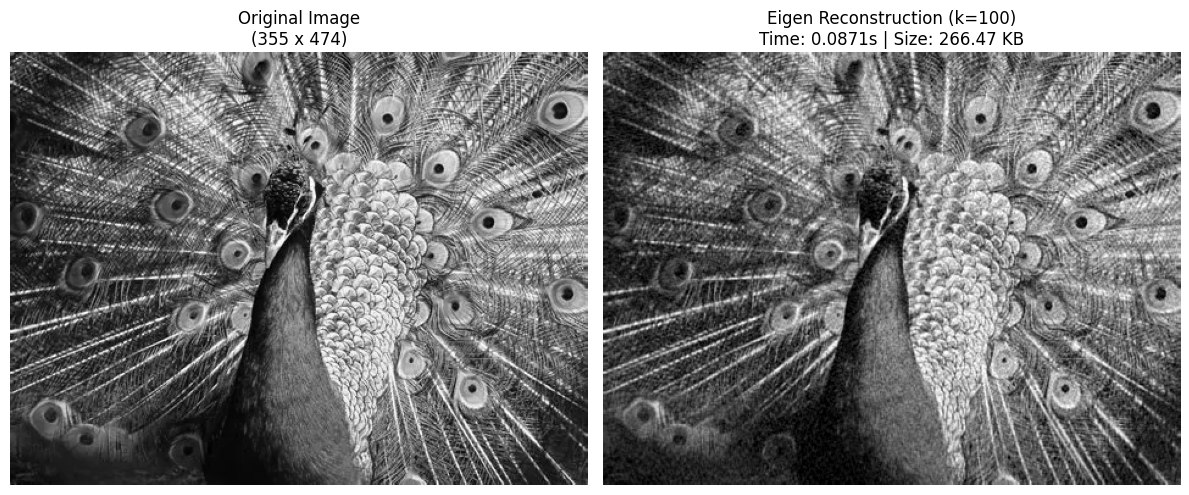

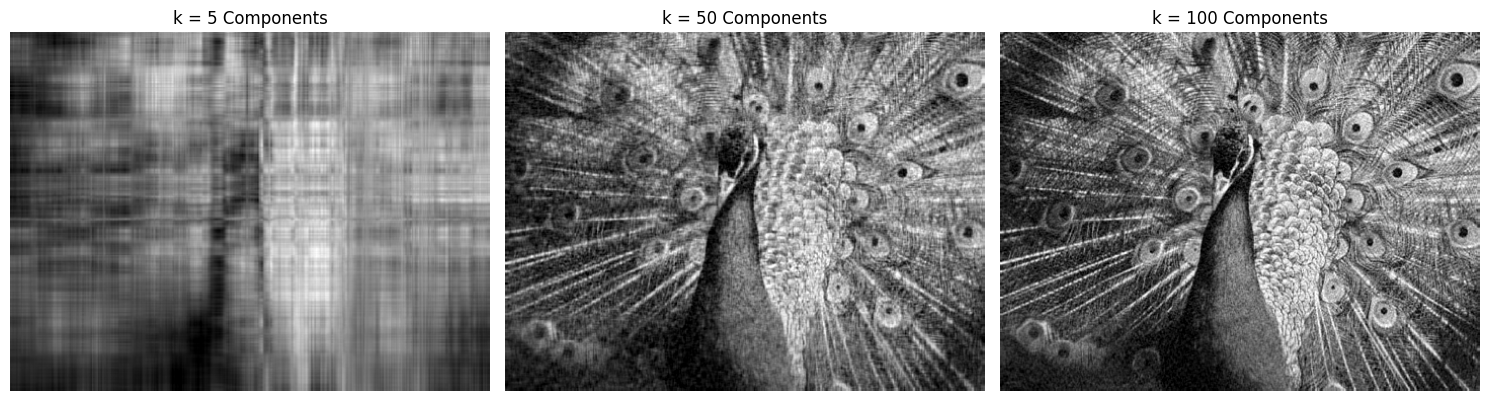

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import time

# ===== Load image locally =====
try:
    img = Image.open("bird.jpg").convert("L")  # Convert to grayscale
except FileNotFoundError:
    print("Error: bird.jpg not found. Please upload the image.")
    exit()

# --- FAIR COMPARISON: USE FULL IMAGE SIZE (NO RESIZE) ---
# We keep the original dimensions to match SVD's workload
X = np.array(img, dtype=np.float64)
h, w = X.shape
print(f"Processing Image Size: {h} x {w} pixels")

# ===== PCA implementation =====
# --- Start Timer ---
start_time = time.time()

# 1. Center the data
mean = np.mean(X, axis=0)
X_c = X - mean

# 2. Compute Covariance Matrix
# rowvar=False means each column is a variable (feature)
cov = np.cov(X_c, rowvar=False)

# 3. Eigen decomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov)

# 4. Sort eigenvalues descending
idx = np.argsort(eigenvalues)[::-1]
eigenvectors = eigenvectors[:, idx]

# --- End Timer ---
end_time = time.time()
eigen_execution_time = end_time - start_time
print(f"Eigen Decomposition Execution Time: {eigen_execution_time:.4f} seconds")

# Number of principal components to keep (k=100 for the main result)
k = 100
W = eigenvectors[:, :k]

# Projection (Compression)
Z = X_c @ W

# Reconstruction
X_rec = (Z @ W.T) + mean
X_rec = np.clip(X_rec, 0, 255).astype(np.uint8)

# --- Measure File Size ---
output_filename = f"eigen_reconstructed_k{k}_full.png"
plt.imsave(output_filename, X_rec, cmap="gray")
file_size_kb = os.path.getsize(output_filename) / 1024
print(f"Compressed File Size (k={k}): {file_size_kb:.2f} KB")
# -------------------------

# ===== Plot results =====
plt.figure(figsize=(12, 5))

# Plot 1: Original
plt.subplot(1, 2, 1)
plt.title(f"Original Image\n({h} x {w})")
plt.imshow(X, cmap="gray")
plt.axis("off")

# Plot 2: Reconstructed (with Time and Size in Title)
plt.subplot(1, 2, 2)
plt.title(f"Eigen Reconstruction (k={k})\nTime: {eigen_execution_time:.4f}s | Size: {file_size_kb:.2f} KB")
plt.imshow(X_rec, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()

# List of k-values to test image reconstruction progression
k_values = [5, 50, 100]

plt.figure(figsize=(15, 5))

for i, k_val in enumerate(k_values):
    # 1. Select the top k eigenvectors
    W_k = eigenvectors[:, :k_val]

    # 2. Project
    Z_k = X_c @ W_k

    # 3. Reconstruct
    X_rec_k = (Z_k @ W_k.T) + mean
    X_rec_k = np.clip(X_rec_k, 0, 255).astype(np.uint8)

    # 4. Plot
    plt.subplot(1, len(k_values), i + 1)
    plt.imshow(X_rec_k, cmap="gray")
    plt.title(f"k = {k_val} Components")
    plt.axis("off")

plt.tight_layout()
plt.show()

SVD Code

SVD Execution Time: 0.0673 seconds
Compressed File Size (r=100): 245.73 KB


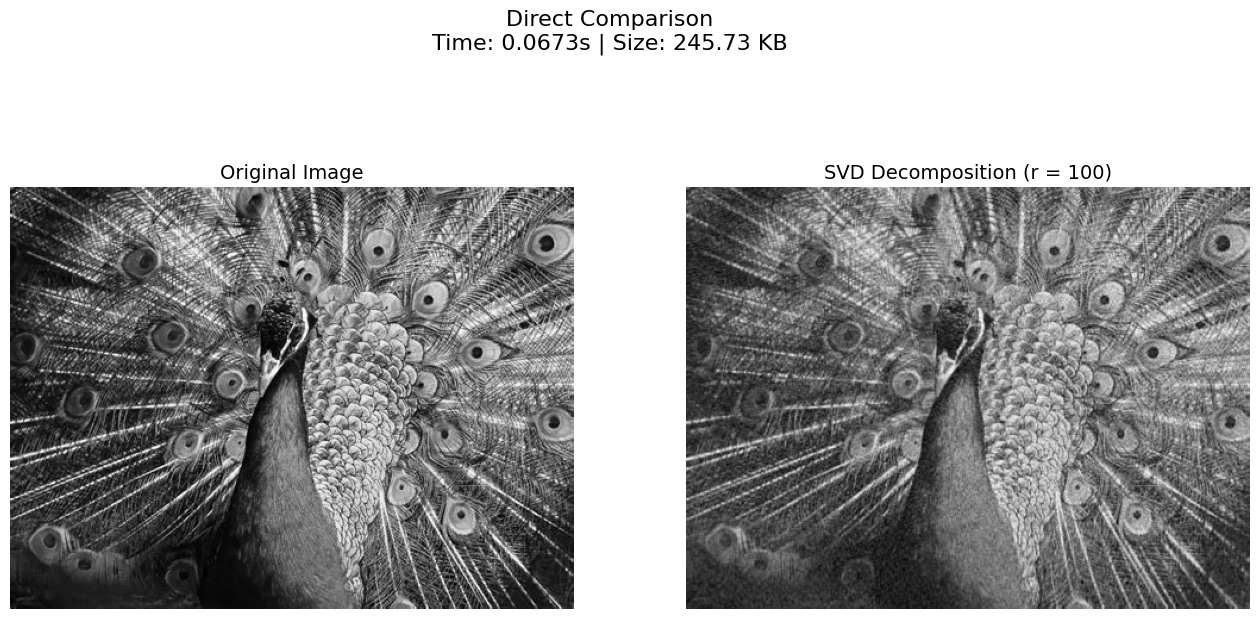

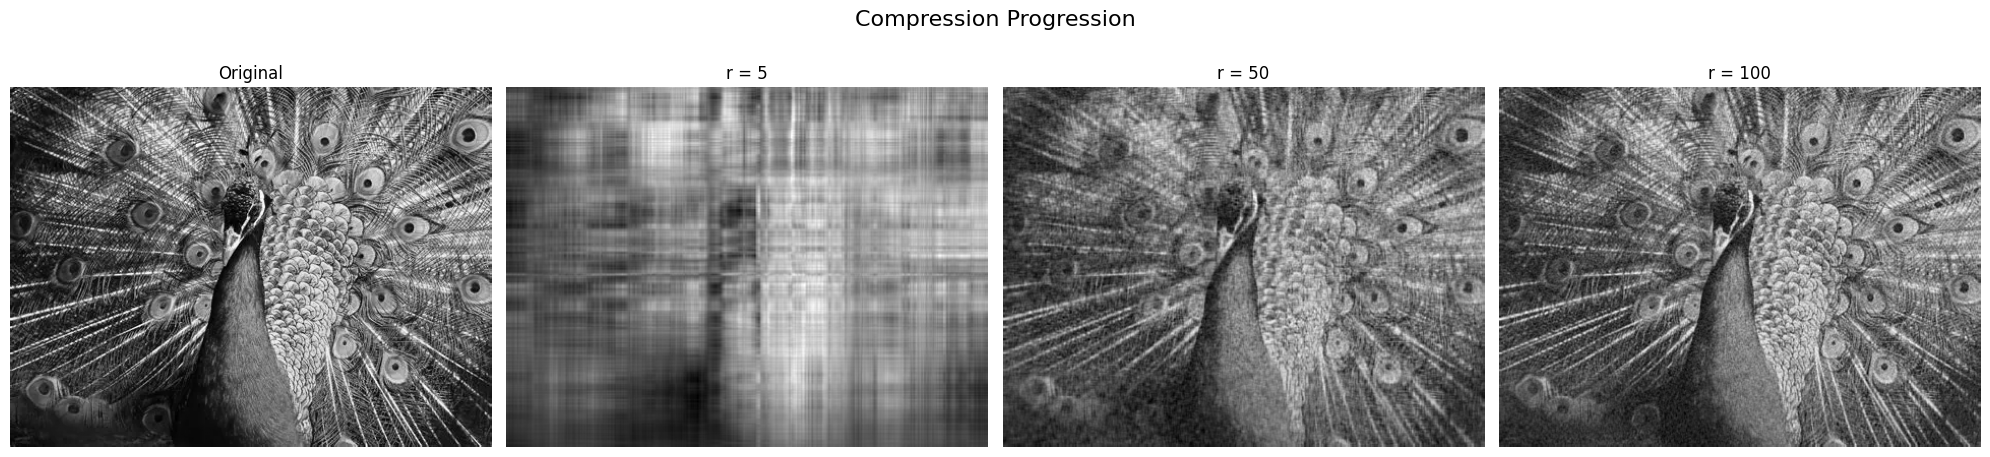

Skipping Part 2: smile.jpg not found.


In [ ]:
from matplotlib.image import imread
import matplotlib.pyplot as plt
import numpy as np
import os
import time  # <--- Added for timing

# Set global figure parameters
plt.rcParams['figure.figsize'] = [16, 8]

# 1. Load Image and Pre-process
# Ensure "bird.jpg" exists in your folder
try:
    A = imread("bird.jpg")
except FileNotFoundError:
    print("Error: bird.jpg not found. Please upload the image.")
    exit()

X = np.mean(A, -1)  # Grayscale

# --- NEW CODE: Measure Execution Time ---
start_time = time.time()

# 2. Compute SVD
U, S, VT = np.linalg.svd(X, full_matrices=False)
S_diag = np.diag(S)

end_time = time.time()
svd_execution_time = end_time - start_time
print(f"SVD Execution Time: {svd_execution_time:.4f} seconds")
# ----------------------------------------

# --- FIGURE 1: Original vs. Constructed (r=100) ---
fig1, ax1 = plt.subplots(1, 2)

# Original
ax1[0].imshow(X, cmap='gray')
ax1[0].set_title("Original Image", fontsize=14)
ax1[0].axis('off')

# Constructed (r=100)
r_final = 100
X_final = U[:, :r_final] @ S_diag[0:r_final, :r_final] @ VT[:r_final, :]
ax1[1].imshow(X_final, cmap='gray')
ax1[1].set_title(f"SVD Decomposition (r = {r_final})", fontsize=14)
ax1[1].axis('off')

# --- NEW CODE: Measure File Size ---
output_filename = f"svd_reconstructed_r{r_final}.png"
plt.imsave(output_filename, X_final, cmap='gray')
file_size_kb = os.path.getsize(output_filename) / 1024
print(f"Compressed File Size (r={r_final}): {file_size_kb:.2f} KB")
# -----------------------------------

plt.suptitle(f"Direct Comparison\nTime: {svd_execution_time:.4f}s | Size: {file_size_kb:.2f} KB", fontsize=16)
plt.show()

# --- FIGURE 2: Progression (r = 1, 5, 20, 100) ---
ranks = [5, 50, 100]
fig2, ax2 = plt.subplots(1, 4, figsize=(20, 5))

# Original for reference
ax2[0].imshow(X, cmap='gray')
ax2[0].set_title("Original")
ax2[0].axis('off')

for i, r in enumerate(ranks):
    Xapprox = U[:, :r] @ S_diag[0:r, :r] @ VT[:r, :]

    # Optional: You can check size for each rank here too if needed

    ax2[i + 1].imshow(Xapprox, cmap='gray')
    ax2[i + 1].set_title(f"r = {r}")
    ax2[i + 1].axis('off')

plt.suptitle("Compression Progression", fontsize=16)
plt.tight_layout()
plt.show()

# === PART 2: Principal Component Visualization (Using smile.jpg as per your code) ===
# Note: Ensure smile.jpg exists or change to bird.jpg
try:
    A_smile = imread("smile.jpg")  # Changed variable name to avoid conflict
    X_smile = np.mean(A_smile, -1)

    # Perform SVD
    U_s, S_s, VT_s = np.linalg.svd(X_smile, full_matrices=False)

    # Calculate the total sum of singular values to find the percentage
    total_importance = np.sum(S_s)

    # Visualize the first 4 Principal Components
    fig, axes = plt.subplots(1, 4, figsize=(20, 6))

    for i in range(4):
        # This is the rank-1 matrix: U_i * S_i * VT_i
        component = np.outer(U_s[:, i], S_s[i] * VT_s[i, :])

        # Calculate the percentage of the total energy this component holds
        importance = (S_s[i] / total_importance) * 100

        axes[i].imshow(component, cmap='gray')

        # Update title to show the percentage!
        axes[i].set_title(f"Principal Component {i + 1}\nImportance: {importance:.2f}%")
        axes[i].axis('off')

    plt.suptitle("Individual Principal Components & Their Importance Scores", fontsize=16)
    plt.tight_layout()
    plt.show()
except FileNotFoundError:
    print("Skipping Part 2: smile.jpg not found.")